In [1]:
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
# TESTING_FOLDER = Path.home() / Path("Desktop/testing")
TESTING_FOLDER = Path("testing/")
METADATA_PATH = TESTING_FOLDER / "metadata.xlsx"

In [3]:
df = pd.read_excel(METADATA_PATH)
id_map = {row.Path: i for i, row in enumerate(df.itertuples(index=False))}
df["id"] = df["Path"].map(id_map)
df

,Path,Description,id
0,1.jpg,"orange cat covers its face with a paw, underne...",0
1,2.jpg,"dog lies in its bed, that is placed on the carpet",1
2,3.jpg,"a tree-shaped-like anthenna, text on the image...",2
3,4.jpg,"a cat with a terrified expression on its face,...",3
4,5.jpg,a drawing of a dog with the bubble over its he...,4
5,6.jpg,"a comic, cat says meow to the woman, woman say...",5
6,7.jpg,image of a man with a mask and a shirt that sa...,6
7,8.jpg,tweet of graph of an lg washing machine intern...,7
8,9.jpg,"""are you winning son?"" meme",8
9,10.jpg,post about computer safety from a trans person,9


In [4]:
TOP_K = 4

In [5]:
def reciprocal_rank(results, correct_id):
    try:
        rank = results.index(correct_id) + 1
        return 1 / rank
    except ValueError:
        return 0.0
    
def hit_at_k(results, correct_id, k):
    return int(correct_id in results[:k])

In [6]:
from cli.platform_file_revealer import PlatformFileRevealer
from cli.table_maker import TableMaker
from infrastructure.services.multimedia_type_detector import MultimediaTypeFinder
from infrastructure.bge_small_encoder import BGEEncoder
from infrastructure.qdrant.qdrant_vdb import QdrantVectorDatabase
from infrastructure.qdrant.qdrant_output_processor import QdrantOutputProcessor
from infrastructure.ml.device import get_device_config
from cli.cli_decoder import CLIDecoder
from settings import *

from dotenv import load_dotenv
import os


load_dotenv("config.env")
hf_token = os.getenv("HF_TOKEN")
config = get_device_config()

encoder = BGEEncoder(hf_token, config)
db = QdrantVectorDatabase()
mtf = MultimediaTypeFinder()

output_processor = QdrantOutputProcessor()
table_maker = TableMaker()
revealer = PlatformFileRevealer()

/Users/williamleonheart/Documents/multimedia-by-prompt-search/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1396.38it/s]


In [7]:
N = len(df)

hit_matrices = {
    k: pd.DataFrame(
        0,
        index=range(N),
        columns=range(N),
        dtype=int
    )
    for k in range(1, TOP_K + 1)
}

In [8]:
for row in df.itertuples(index=False):
    target_id = row.id
    query_text = row.Description
    real_path = row.Path

    embedding = encoder.encode(query_text)
    results = db.search(embedding, TOP_K)

    rows = output_processor.create_dict_of_rows(results)

    print("\n" + "=" * 120)
    print(f"QUERY (real description): {query_text}")
    print(f"GROUND TRUTH PATH: {real_path}")
    print(f"GROUND TRUTH ID: {target_id}")

    print("\nTOP RESULTS:")

    retrieved_ids = []

    for rank, r in enumerate(rows):
        path = r.get("path")
        db_desc = r.get("text_description", None)
        score = r.get("score", None)

        file_id = id_map.get(Path(path).name) if path else None
        retrieved_ids.append(file_id)

        print(f"\nRank {rank + 1}")
        print(f"Path: {path}")
        print(f"DB Description: {db_desc}")
        print(f"Score: {score}")
        print(f"Mapped ID: {file_id}")

        for k in range(1, TOP_K + 1):
            if target_id in retrieved_ids[:k]:
                hit_matrices[k].loc[target_id, target_id] = 1

    hit1 = hit_at_k(retrieved_ids, target_id, 1)
    print(f"\nHIT@1: {hit1}")


QUERY (real description): orange cat covers its face with a paw, underneath it there is an emoji with the same expression
GROUND TRUTH PATH: 1.jpg
GROUND TRUTH ID: 0

TOP RESULTS:

Rank 1
Path: images/vid_1.mp4
DB Description: This meme, sourced from a YouTube video, features a screenshot from a video on a blurry car driving down the road while rain can be seen dripping from the car's roof. The car appears to be moving at a brisk speed, possibly during a thunderstorm, as indicated by the heavy rain and the car's roof g
Score: 0.5223446630164026
Mapped ID: 20

Rank 2
Path: images/vid_1.mp4
DB Description: The image is a screenshot set against a dark blue or purple background, depicting a text overlay in white text. The text reads: "when the U.S. is entering its 20th war with the middle East of the year and my paper straw has disintegrated into my MCG sprite but at least when
Score: 0.5149177637207658
Mapped ID: 20

HIT@1: 0

QUERY (real description): dog lies in its bed, that is placed

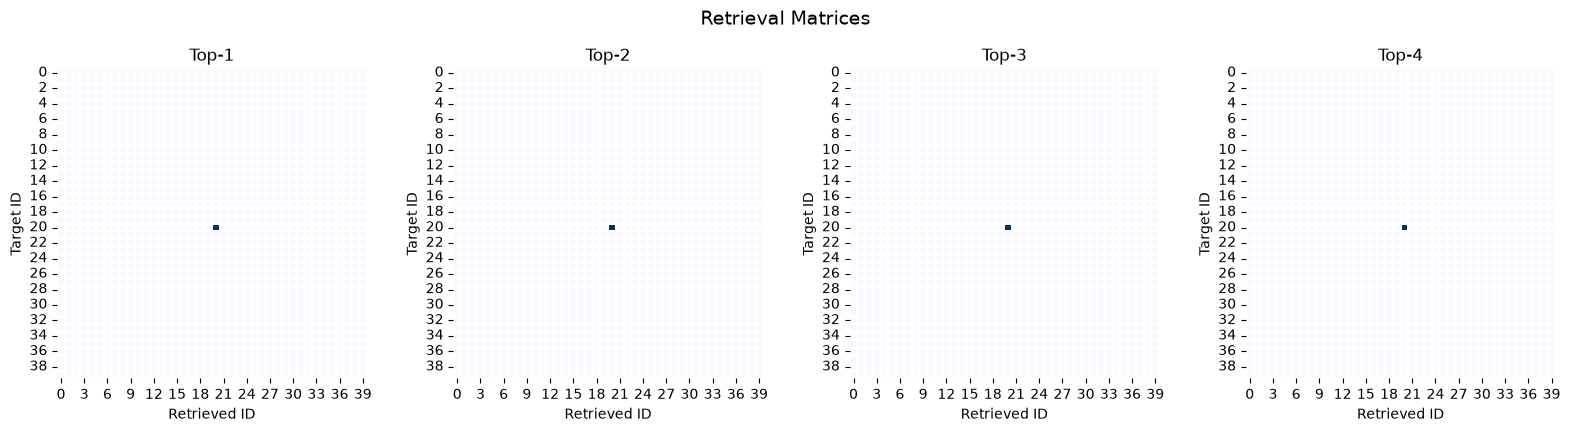

In [9]:
import math

fig_cols = TOP_K
fig_rows = math.ceil(len(hit_matrices) / fig_cols)

fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(fig_cols * 4, fig_rows * 4))
axes = axes.flatten()

for idx, (k, matrix) in enumerate(hit_matrices.items()):
    sns.heatmap(
        matrix,
        ax=axes[idx],
        cmap="Blues",
        square=True,
        cbar=False,
        linewidths=0.2,
    )
    axes[idx].set_title(f"Top-{k}")
    axes[idx].set_xlabel("Retrieved ID")
    axes[idx].set_ylabel("Target ID")

for idx in range(len(hit_matrices), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Retrieval Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
len(df)

40

In [11]:
db.client.close()